# **Visual Translation**: Converting all the telugu(for now) text into tamil text retianing all the consistency to maintain the originality

## GPU Check up

In [ ]:
import torch
print("CUDA available:", torch
      .cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")



CUDA available: True
GPU: Tesla T4


## Install the dependices

In [ ]:
## !pip install -q torch torchvision torchaudio
!pip install -q opencv-python shapely scikit-image
!pip install -q numpy pillow matplotlib
!pip install -q gdown


## Git Hub cloning / importing / downloading the **craft model** for **Text Detection**

In [ ]:
!git clone https://github.com/clovaai/CRAFT-pytorch.git

%cd CRAFT-pytorch
!gdown https://drive.google.com/uc?id=1Jk4eGD7crsqCCg9C9VjCLkMN3ze8kutZ


Cloning into 'CRAFT-pytorch'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 59 (delta 27), reused 24 (delta 24), pack-reused 23 (from 1)
Receiving objects: 100% (59/59), 1.69 MiB | 7.71 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/CRAFT-pytorch
Downloading...
From: https://drive.google.com/uc?id=1Jk4eGD7crsqCCg9C9VjCLkMN3ze8kutZ
To: /content/CRAFT-pytorch/craft_mlt_25k.pth
100% 83.2M/83.2M [00:01<00:00, 72.8MB/s]


In [ ]:
## Creating the folder for test Images
!mkdir -p data/images


## ------------- **Upload the Images** -------------

## Text Area Detection

In [ ]:
# Ensure the import of model_urls is commented out
!sed -i 's/^from torchvision.models.vgg import model_urls/#&/' basenet/vgg16_bn.py
# Comment out the line that uses model_urls unconditionally at line 25
!sed -i '25s/^/#/' basenet/vgg16_bn.py
# Ensure that craft.py calls vgg16_bn with pretrained=False
!sed -i 's/vgg16_bn(pretrained=True, freeze=True)/vgg16_bn(pretrained=False, freeze=True)/g' craft.py
# Run the test script
!python test.py \
--trained_model=craft_mlt_25k.pth \
--test_folder=data/images \
--cuda=True

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Loading weights from checkpoint (craft_mlt_25k.pth)
elapsed time : 1.3965318202972412s


In [ ]:
# View all the results
!ls result

import cv2
import matplotlib.pyplot as plt
import os

result_dir = "result"

# Define a list of valid image extensions
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

for img_name in os.listdir(result_dir):
    # Check if the file is an image before processing
    if img_name.lower().endswith(image_extensions):
        img_path = os.path.join(result_dir, img_name)
        img = cv2.imread(img_path)

        # Ensure the image was loaded successfully
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(8,6))
            plt.imshow(img)
            plt.title(img_name)
            plt.axis("off")
            plt.show()
        else:
            print(f"Warning: Could not load image {img_name}")
    else:
        print(f"Skipping non-image file: {img_name}")

Output hidden; open in https://colab.research.google.com to view.

# **Choose the images**

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_path = "data/images/img6.JPG"
img = cv2.imread(img_path)
res = "result/res_img6.txt"

# Check if the image was loaded successfully before proceeding
if img is None:
    print(f"Error: Could not load image from {img_path}. Please check the path and file existence.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


## Load Craft Boxes

In [ ]:
import numpy as np

def load_craft_boxes(txt_path):
    boxes = []
    with open(txt_path) as f:
        for line in f:
            pts = np.array(list(map(int, line.strip().split(',')))).reshape(4,2)
            x1, y1 = pts.min(axis=0)
            x2, y2 = pts.max(axis=0)
            boxes.append({
                "bbox": (x1, y1, x2, y2),
                "cx": (x1 + x2) / 2,
                "cy": (y1 + y2) / 2,
                "w": x2 - x1,
                "h": y2 - y1
            })
    return boxes

boxes = load_craft_boxes(res)
print("Total boxes:", len(boxes))


Total boxes: 58


## Group Boxes into Text areas

In [ ]:
def is_similar_height(a, b, ratio=0.6):
    return min(a["h"], b["h"]) / max(a["h"], b["h"]) > ratio

def vertical_close(a, b, tol=1.5):
    return abs(a["cy"] - b["cy"]) < tol * max(a["h"], b["h"])

def build_text_areas(boxes):
    boxes = sorted(boxes, key=lambda b: b["cy"])
    areas = []

    for box in boxes:
        placed = False
        for area in areas:
            ref = area[0]
            if vertical_close(ref, box) and is_similar_height(ref, box):
                area.append(box)
                placed = True
                break
        if not placed:
            areas.append([box])

    return areas

areas = build_text_areas(boxes)
print("Total areas:", len(areas))


Total areas: 12


## Visualize the text areas

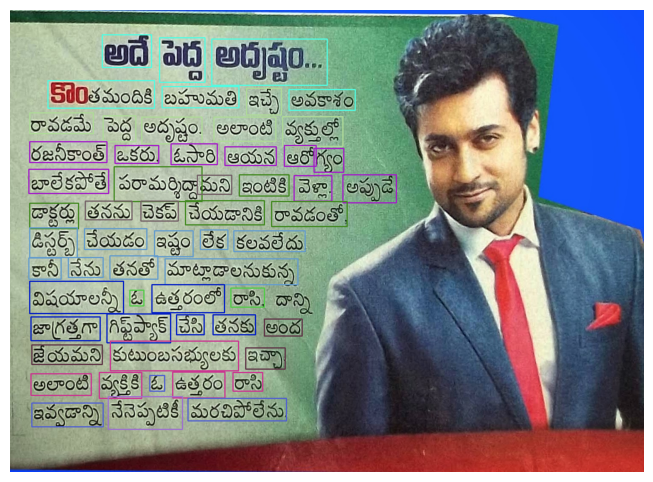

In [ ]:
import random

def visualize_areas(img, areas):
    vis = img.copy()
    for area in areas:
        color = tuple(random.randint(0,255) for _ in range(3))
        for b in area:
            x1,y1,x2,y2 = b["bbox"]
            cv2.rectangle(vis, (x1,y1), (x2,y2), color, 2)
    plt.figure(figsize=(12,6))
    plt.imshow(vis)
    plt.axis("off")
    plt.show()

visualize_areas(img, areas)


# **Area Purification**

In [ ]:
# Compute Area Bounding Boxes
def area_bbox(area):
    x1 = min(b["bbox"][0] for b in area)
    y1 = min(b["bbox"][1] for b in area)
    x2 = max(b["bbox"][2] for b in area)
    y2 = max(b["bbox"][3] for b in area)
    return (x1, y1, x2, y2)

# Area Validation function
def is_valid_text_area(area, img_shape):
    h_img, w_img, _ = img_shape

    x1,y1,x2,y2 = area_bbox(area)
    area_w = x2 - x1
    area_h = y2 - y1
    area_size = area_w * area_h

    # Rule 1: extremely tiny areas are noise (always)
    if area_w < 15 or area_h < 15:
        return False

    # Rule 2: microscopic relative to image
    if area_size < 0.0004 * (w_img * h_img):
        return False

    # Rule 3: single-box areas are allowed IF they are big enough
    if len(area) == 1:
        if area_size < 0.002 * (w_img * h_img):
            return False
        return True

    # Rule 4: multi-box areas are usually valid
    return True





In [ ]:
# Apply Validation
valid_areas = []
noise_areas = []

for area in areas:
    if is_valid_text_area(area, img.shape):
        valid_areas.append(area)
    else:
        noise_areas.append(area)

print("Valid areas:", len(valid_areas))
print("Noise areas:", len(noise_areas))


Valid areas: 12
Noise areas: 0


## Visualize valid and noise areas

In [ ]:
def visualize_valid_areas(img, valid_areas, noise_areas):
    vis = img.copy()

    # Green = valid
    for area in valid_areas:
        for b in area:
            x1,y1,x2,y2 = b["bbox"]
            cv2.rectangle(vis,(x1,y1),(x2,y2),(0,255,0),2)

    # Red = noise
    for area in noise_areas:
        for b in area:
            x1,y1,x2,y2 = b["bbox"]
            cv2.rectangle(vis,(x1,y1),(x2,y2),(255,0,0),1)

    plt.figure(figsize=(12,6))
    plt.imshow(vis)
    plt.axis("off")
    plt.show()


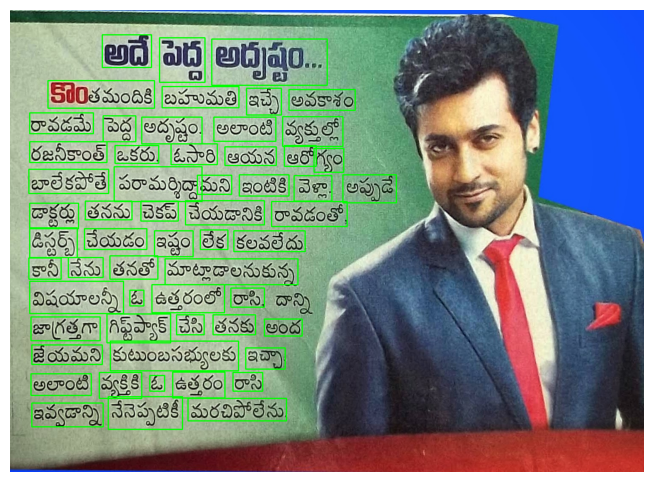

In [ ]:
visualize_valid_areas(img,valid_areas,noise_areas)

## **OCR -Text Extraction from Areas**

In [ ]:
# Install Dependencies
!pip install -q easyocr

In [ ]:
import easyocr

reader = easyocr.Reader(
    ['te', 'en'],   # Telugu + English (numbers come via English)
    gpu=True
)

# ----------------- Crop Area from original image -----------------
def crop_area(img, area):
    x1,y1,x2,y2 = area_bbox(area)
    return img[y1:y2, x1:x2]

# ----------------- Run OCR ON Areas -----------------
def ocr_area(img, area):
    crop = crop_area(img, area)

    if crop.size == 0:
        return []

    results = reader.readtext(
        crop,
        detail=1,
        paragraph=False
    )

    ocr_outputs = []
    for r in results:
        bbox, text, conf = r

        xs = [p[0] for p in bbox]
        ys = [p[1] for p in bbox]

        x1, x2 = min(xs), max(xs)
        y1, y2 = min(ys), max(ys)

        ocr_outputs.append({
            "text": text.strip(),
            "conf": float(conf),
            "bbox": bbox,
            "cx": (x1 + x2) / 2,
            "cy": (y1 + y2) / 2,
            "w": x2 - x1,
            "h": y2 - y1
        })

    return ocr_outputs


## Clustering Lines in the area to correct the order of words


In [ ]:
#---------Line Clustering Function---------
def cluster_into_lines(words):
    words = sorted(words, key=lambda w: w["cy"])
    lines = []

    for w in words:
        placed = False
        for line in lines:
            # Use median height of line, not first word
            line_cy = sum(x["cy"] for x in line) / len(line)
            line_h  = sum(x["h"] for x in line) / len(line)

            if abs(w["cy"] - line_cy) < 0.45 * line_h:
                line.append(w)
                placed = True
                break

        if not placed:
            lines.append([w])

    return lines


#-----------Sort words in each line for right ordering-------------
def sort_line_left_to_right(line):
    return sorted(line, key=lambda w: w["cx"])

#------------Clean line order--------------
def clean_line_order(lines):
    cleaned = []
    last_y = -1

    for line in lines:
        y = min(w["cy"] for w in line)
        if y >= last_y:
            cleaned.append(line)
            last_y = y

    return cleaned

#------------Build the corrected sentence ------------------
def reconstruct_area_sentence(ocr_words):
    lines = cluster_into_lines(ocr_words)
    lines = sorted(lines, key=lambda l: min(w["cy"] for w in l))
    lines = clean_line_order(lines)


    sentence_words = []
    for line in lines:
        ordered = sort_line_left_to_right(line)
        sentence_words.extend([w["text"] for w in ordered])

    return sentence_words





In [ ]:
# ----------------- Telugu Detection Helps -----------------
import re

TELUGU_RANGE = r'[\u0C00-\u0C7F]'

def count_telugu_chars(text):
    return len(re.findall(TELUGU_RANGE, text))

def contains_telugu(text):
    return count_telugu_chars(text) > 0

# ----------------- AREA-LEVEL TELUGU LEGITIMACY -----------------
def is_telugu_area(ocr_results, min_telugu_chars=2):
    combined = " ".join(r["text"] for r in ocr_results)
    return count_telugu_chars(combined) >= min_telugu_chars


## Seperate Telugu and NON Teugu Text

In [ ]:
def split_telugu_and_other(ocr_results):
    telugu_parts = []
    other_parts = []

    for r in ocr_results:
        text = r["text"]
        if not text:
            continue

        if contains_telugu(text):
            telugu_parts.append(text)
        else:
            other_parts.append(text)

    return telugu_parts, other_parts


## Apply to all Valid Areas

In [ ]:
processed_areas = []

for area in valid_areas:
    ocr_results = ocr_area(img, area)

    if not ocr_results:
        continue

    if not is_telugu_area(ocr_results):
        continue

    ordered_words = reconstruct_area_sentence(ocr_results)

    processed_areas.append({
        "area_bbox": area_bbox(area),
        "ordered_words": ordered_words,
        "raw_ocr": ocr_results
    })



In [ ]:
# Incpection
for a in processed_areas:
    print("AREA:", a["area_bbox"])
    print("TELUGU:", a["raw_ocr"])
    print("ordered Words", a["ordered_words"])
    print("-" * 40)


AREA: (np.int64(89), np.int64(58), np.int64(813), np.int64(236))
TELUGU: [{'text': 'అదే పెద్ద అదృర్టం .', 'conf': 0.7189276201317959, 'bbox': [[np.int32(119), 0], [np.int32(667), 0], [np.int32(667), np.int32(127)], [np.int32(119), np.int32(127)]], 'cx': np.float64(393.0), 'cy': np.float64(63.5), 'w': np.int32(548), 'h': np.int32(127)}, {'text': 'కెంతమందికి బహుమతి ఇచే', 'conf': 0.5579853485940246, 'bbox': [[0, np.int32(101)], [np.int32(551), np.int32(101)], [np.int32(551), 178], [0, 178]], 'cx': np.float64(275.5), 'cy': np.float64(139.5), 'w': np.int32(551), 'h': np.int32(77)}, {'text': 'అవకాశం', 'conf': 0.978586631948568, 'bbox': [[np.int32(564), np.int32(128)], [np.int32(718), np.int32(128)], [np.int32(718), np.int32(176)], [np.int32(564), np.int32(176)]], 'cx': np.float64(641.0), 'cy': np.float64(152.0), 'w': np.int32(154), 'h': np.int32(48)}]
ordered Words ['అదే పెద్ద అదృర్టం .', 'కెంతమందికి బహుమతి ఇచే', 'అవకాశం']
----------------------------------------
AREA: (np.int64(46), np.int6